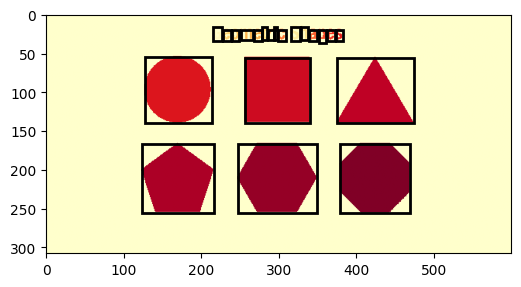

In [ ]:
#2	VIẾT CHƯƠNG TRÌNH GÁN NHÃN ẢNH
# 2.1 Chương trình gắn nhãn ảnh
from PIL import Image
import numpy as np
import imageio.v2 as iio
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

data = Image.open('geometric.png').convert('L')  
a = np.asarray(data)
thres = threshold_otsu(a)
b = a > thres  
c = label(b)
c_uint8 = (c * 255 / c.max()).astype(np.uint8)
cl = Image.fromarray(c_uint8)
iio.imsave('label_output.jpg', c_uint8)
d = regionprops(c)
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 6))
ax.imshow(c, cmap='YlOrRd')

for i in d:
    lr, lc, ur, uc = i['BoundingBox']
    rec_width = uc - lc
    rec_height = ur - lr
    rect = mpatches.Rectangle((lc, lr), rec_width, rec_height, fill=False,
                              edgecolor='black', linewidth=2)
    ax.add_patch(rect)

plt.show()


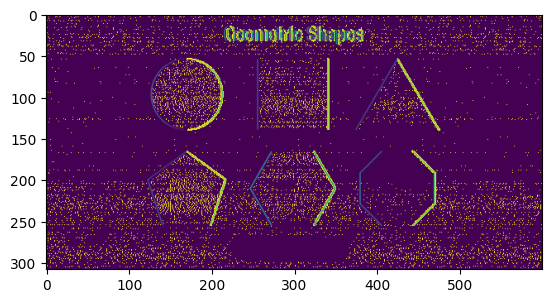

In [ ]:
#2.2 Dò tìm cạnh theo chiều dọc
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu
data = Image.open('geometric.png') .convert('L')
bmg = abs(data - nd.shift(data, (0, 1), order=0))
plt.imshow (bmg)
plt.show()


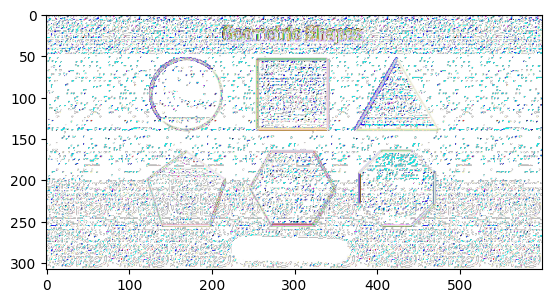

In [7]:
#2.3 Dò tìm cạnh với Sobel Filter
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu
data = Image.open('geometric.png')
a = nd.sobel (data, axis=0)
b=nd.sobel (data, axis=1)
bmg =  abs (a) + abs (b)
plt.imshow (bmg)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-49.800000000000004..255.0].


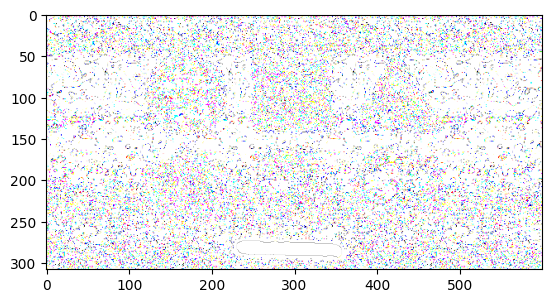

In [12]:
#2.4 Xác định góc của đối tượng
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

def Harris(indata, alpha=0.2):
    x = nd.sobel(indata, 0)
    y = nd.sobel(indata, 1)
    x1 = x ** 2
    y1 = y ** 2
    xy = abs (x * y)
    x1 = nd.gaussian_filter(x1, 3)
    y1 = nd.gaussian_filter(y1, 3)
    xy = nd.gaussian_filter(xy, 3)
    detC = x1 * y1 - xy ** 2
    trc = x1 + y1
    R = detC - alpha * (trc ** 2)
    return R
data = Image.open('geometric.png')
bmg = Harris(data)
plt.imshow(bmg)
plt.show()


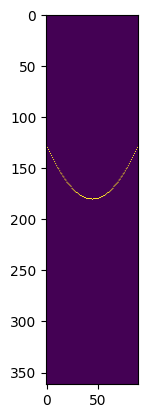

In [13]:
#2.5.	Dò tìm hình dạng cụ thể trong ảnh với Hough Transform
#2.5.1	Dò tìm đường thẳng trong ảnh
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

def LineHough(data, gamma):
    V, H = data.shape
    R = int(np.sqrt(V * V + H * H))
    ho = np.zeros((R, 90), float) #Hough space
    w = data + 0
    ok = 1
    theta = np.arange(90)/180.0 * np.pi
    tp = np.arange(90).astype(float)

    while ok:
        mx = w.max()
        if mx < gamma:
            ok = 0
        else:
            v,h = divmod(w.argmax(), H)
            y = V - v
            x = h
            rh = x * np.cos(theta) + y * np.sin(theta)
            for i in range(len(rh)):
                if 0 <= rh[i] < R and 0 <= tp[i] < 90:
                    ho[int(rh[i]), int(tp[i])] += mx
            w[v,h] = 0
    return ho

data = np.zeros((256, 256))
data[128, 128] = 1
bmg = LineHough(data, 0.5)
plt.imshow(bmg)
plt.show()

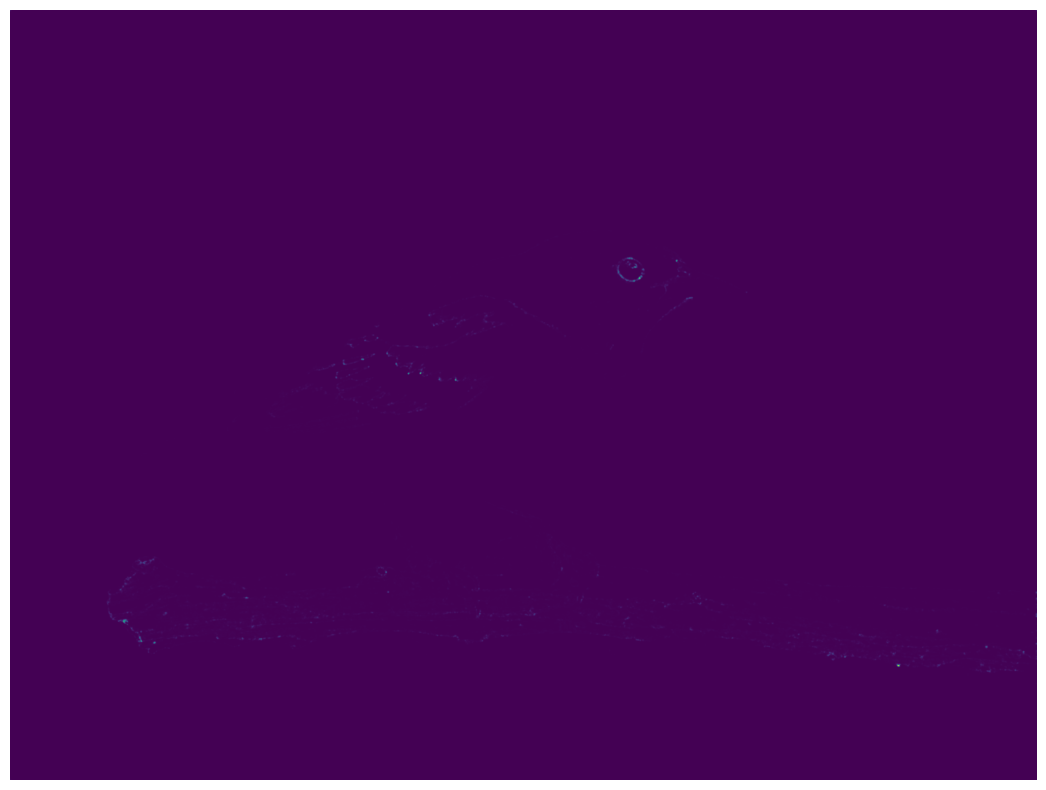

In [14]:
#2.5.2	Dò tìm đường tròn trong ảnh
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.feature import corner_harris
from skimage.color import rgb2gray

data = iio.imread('bird.png')
image_gray = rgb2gray(data)
coordinate = corner_harris(image_gray, k = 0.001)

plt.figure(figsize=(20,10))
plt.imshow(coordinate)
plt.axis('off')
plt.show()

In [ ]:
#2.6	Image matching
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import corner_harris, corner_peaks
from skimage.color import rgb2gray
from scipy.spatial.distance import cdist
import imageio.v2 as iio

def get_descriptors(image_gray, corners, window_size=5):
    descriptors = []
    valid_points = []
    half = window_size // 2
    h, w = image_gray.shape
    for y, x in corners:
        if y - half >= 0 and y + half < h and x - half >= 0 and x + half < w:
            window = image_gray[y-half:y+half+1, x-half:x+half+1].flatten()
            descriptors.append(window)
            valid_points.append((y, x))
    return np.array(descriptors), valid_points

def match_descriptors(desc1, desc2, threshold=0.5):
    distances = cdist(desc1, desc2, 'euclidean')
    matches = []
    for i in range(len(desc1)):
        j = np.argmin(distances[i])
        if distances[i, j] < threshold:
            matches.append((i, j))
    return matches

img1 = rgb2gray(iio.imread('image1.png'))
img2 = rgb2gray(iio.imread('image2.png'))

corners1 = corner_peaks(corner_harris(img1), min_distance=5)
corners2 = corner_peaks(corner_harris(img2), min_distance=5)

desc1, pts1 = get_descriptors(img1, corners1)
desc2, pts2 = get_descriptors(img2, corners2)

matches = match_descriptors(desc1, desc2, threshold=5.0)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
combined = np.hstack((img1, img2))
ax.imshow(combined, cmap='gray')

for i1, i2 in matches:
    y1, x1 = pts1[i1]
    y2, x2 = pts2[i2]
    ax.plot([x1, x2 + img1.shape[1]], [y1, y2], 'r-', linewidth=0.8)
    ax.plot(x1, y1, 'go', markersize=3)
    ax.plot(x2 + img1.shape[1], y2, 'bo', markersize=3)

ax.set_title('Image Matching using Harris Corners')
ax.axis('off')
plt.tight_layout()
plt.show()
